In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
jobs = pd.read_csv("../data/processed/cleaned_jobs.csv")
print("Job dataset loaded successfully!")
print("Number of jobs:", len(jobs))
print("Number of columns:", len(jobs.columns))
jobs.head()

Job dataset loaded successfully!
Number of jobs: 61773
Number of columns: 13


,job_id,job_role,company,experience,salary,location,rating,reviews,key_skills,posted_on,job_link,company_link,job_text
0,181224917811,GN - Strategy - MC - SC&O - SC Digital Core Ar...,Accenture,3-6 Yrs,Not disclosed,"Hyderabad, Chennai, Bengaluru",3.9,52479 Reviews,"sap ariba,presentation skills,solution impleme...",1 Day Ago,https://www.naukri.com/job-listings-gn-strateg...,https://www.naukri.com/accenture-jobs-careers-...,GN - Strategy - MC - SC&O - SC Digital Core Ar...
1,181224906322,GN - SC&O - BPM - Senior Manager,Accenture,2-4 Yrs,Not disclosed,"Gurugram, Bengaluru, Delhi / NCR",3.9,52479 Reviews,"spend analysis,market research,sales and opera...",1 Day Ago,https://www.naukri.com/job-listings-gn-sc-o-bp...,https://www.naukri.com/accenture-jobs-careers-...,GN - SC&O - BPM - Senior Manager spend analysi...
2,181224906320,GN - SC&O - S&P - CLM - Associate Manager,Accenture,1-5 Yrs,Not disclosed,"Gurugram, Bengaluru, Delhi / NCR",3.9,52479 Reviews,"Sourcing,PowerBI,procurement,digital sourcing,...",1 Day Ago,https://www.naukri.com/job-listings-gn-sc-o-s-...,https://www.naukri.com/accenture-jobs-careers-...,GN - SC&O - S&P - CLM - Associate Manager Sour...
3,181224904080,GN - SONG - Service - Command Center of Future...,Accenture,12-15 Yrs,Not disclosed,"New Delhi, Gurugram, Bengaluru",3.9,52479 Reviews,"cloud solutions,WFM solutions,AI,Customer Enga...",1 Day Ago,https://www.naukri.com/job-listings-gn-song-se...,https://www.naukri.com/accenture-jobs-careers-...,GN - SONG - Service - Command Center of Future...
4,181224904079,GN - SC&O - S&P - CLM - Manager,Accenture,8-13 Yrs,Not disclosed,"New Delhi, Gurugram, Bengaluru",3.9,52479 Reviews,"Procurement,Sourcing,Supply Chain Management,p...",1 Day Ago,https://www.naukri.com/job-listings-gn-sc-o-s-...,https://www.naukri.com/accenture-jobs-careers-...,"GN - SC&O - S&P - CLM - Manager Procurement,So..."


In [3]:
job_matrix = joblib.load("../models/job_matrix.pkl")
print("Job TF-IDF matrix loaded successfully!")
print("Matrix shape:", job_matrix.shape)

Job TF-IDF matrix loaded successfully!
Matrix shape: (61773, 10000)


In [4]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
job_reduced = svd.fit_transform(job_matrix)
print("Dimensionality reduction completed!")
print("Original shape:", job_matrix.shape)
print("Reduced shape:", job_reduced.shape)

Dimensionality reduction completed!
Original shape: (61773, 10000)
Reduced shape: (61773, 100)


In [5]:
inertia_values = []
silhouette_values = []
k_values = range(2, 9)
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(job_reduced)
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(
        silhouette_score(job_reduced, cluster_labels)
    )
print("Clustering evaluation completed!")
for i in range(len(k_values)):
    print(
        "K =", k_values[i],
        "| Inertia =", round(inertia_values[i], 2),
        "| Silhouette Score =", round(silhouette_values[i], 4)
    )

Clustering evaluation completed!
K = 2 | Inertia = 19433.75 | Silhouette Score = 0.1057
K = 3 | Inertia = 18803.21 | Silhouette Score = 0.1139
K = 4 | Inertia = 18303.99 | Silhouette Score = 0.0855
K = 5 | Inertia = 17795.03 | Silhouette Score = 0.1018
K = 6 | Inertia = 17458.58 | Silhouette Score = 0.0815
K = 7 | Inertia = 17144.55 | Silhouette Score = 0.0843
K = 8 | Inertia = 16919.06 | Silhouette Score = 0.0817


In [6]:
best_k = 3
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
job_clusters = kmeans.fit_predict(job_reduced)
print("Final K-Means clustering completed!")
print("Number of clusters:", best_k)
print("Cluster labels created:", len(job_clusters))

Final K-Means clustering completed!
Number of clusters: 3
Cluster labels created: 61773


In [7]:
jobs["cluster"] = job_clusters
print("Cluster labels added to job dataset!")
jobs[["job_role", "key_skills", "cluster"]].head(10)

Cluster labels added to job dataset!


,job_role,key_skills,cluster
0,GN - Strategy - MC - SC&O - SC Digital Core Ar...,"sap ariba,presentation skills,solution impleme...",2
1,GN - SC&O - BPM - Senior Manager,"spend analysis,market research,sales and opera...",2
2,GN - SC&O - S&P - CLM - Associate Manager,"Sourcing,PowerBI,procurement,digital sourcing,...",2
3,GN - SONG - Service - Command Center of Future...,"cloud solutions,WFM solutions,AI,Customer Enga...",2
4,GN - SC&O - S&P - CLM - Manager,"Procurement,Sourcing,Supply Chain Management,p...",2
5,R&R FS - Python Full Stack -Manager,"Data analysis,Data management,Analytical,Consu...",2
6,R&R FS - Python Full Stack -Senior Associate,"Data analysis,Automation,Analytical,Consulting...",2
7,R&R FS-Reg Reporting-Manager,"Data analysis,Automation,Data management,Busin...",2
8,Sr Advanced Embedded Engr,"RTOS,Test case execution,C++,Linux,Programming...",2
9,Sr Advanced Embedded Engr,"Software testing,RTOS,Test case execution,C++,...",2


In [8]:
cluster_counts = jobs["cluster"].value_counts().sort_index()
print("Number of jobs in each cluster:\n")
print(cluster_counts)

Number of jobs in each cluster:

cluster
0     6805
1     2717
2    52251
Name: count, dtype: int64


In [9]:
for cluster_number in sorted(jobs["cluster"].unique()):
    print("CLUSTER", cluster_number)
    cluster_jobs = jobs[jobs["cluster"] == cluster_number]
    print(cluster_jobs["job_role"].head(15).to_string(index=False))

CLUSTER 0
                              Sales Ops Specialist
Hospital Business Manager - Govt Institutional ...
     Talent Acquisition Specialist  - Sales Hiring
            Sr Manager - Sales (Building End User)
             Admission Officer - Sales & Marketing
                        Territory Head - Bangalore
          Manager Franchisee Expansion - Bangalore
                    Area Sales Manager - Bangalore
                    Business Development Associate
General Manager - Corporate Sales - South (Trav...
Walk-in Interviews For RM/Sr. Relationship Mana...
              Area Manager-Channel sales-Bangalore
          Freshers - Sales & Marketing - Bangalore
   Urgent Openings - Sales & Marketing - Bangalore
                        Tracxn - Sales Head (EMEA)
CLUSTER 1
                         Advanced Business Analyst
                                         Tech Lead
               GN-Industrial-SAP Platforms-Manager
 AES- Oracle, Salesforce, SAP- Associate - Operate
           

In [10]:
cluster_names = {
    0: "Sales & Business Development",
    1: "Technology & IT Consulting",
    2: "General & Other Professional Roles"
}
jobs["cluster_name"] = jobs["cluster"].map(cluster_names)
print("Cluster names assigned successfully!")
jobs[["job_role", "cluster", "cluster_name"]].head(10)

Cluster names assigned successfully!


,job_role,cluster,cluster_name
0,GN - Strategy - MC - SC&O - SC Digital Core Ar...,2,General & Other Professional Roles
1,GN - SC&O - BPM - Senior Manager,2,General & Other Professional Roles
2,GN - SC&O - S&P - CLM - Associate Manager,2,General & Other Professional Roles
3,GN - SONG - Service - Command Center of Future...,2,General & Other Professional Roles
4,GN - SC&O - S&P - CLM - Manager,2,General & Other Professional Roles
5,R&R FS - Python Full Stack -Manager,2,General & Other Professional Roles
6,R&R FS - Python Full Stack -Senior Associate,2,General & Other Professional Roles
7,R&R FS-Reg Reporting-Manager,2,General & Other Professional Roles
8,Sr Advanced Embedded Engr,2,General & Other Professional Roles
9,Sr Advanced Embedded Engr,2,General & Other Professional Roles


In [11]:
print(jobs.groupby(["cluster", "cluster_name"]).size())

cluster  cluster_name                      
0        Sales & Business Development           6805
1        Technology & IT Consulting             2717
2        General & Other Professional Roles    52251
dtype: int64


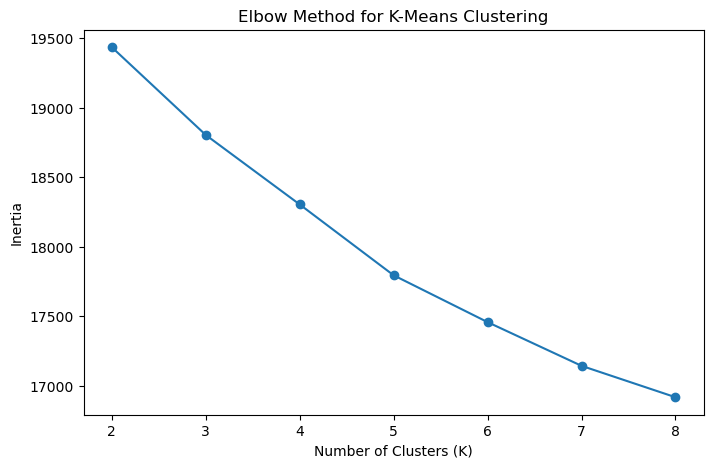

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia_values, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Clustering")
plt.show()

In [13]:
pca = PCA(n_components=2, random_state=42)
job_pca = pca.fit_transform(job_reduced)
print("PCA completed successfully!")
print("PCA shape:", job_pca.shape)

PCA completed successfully!
PCA shape: (61773, 2)


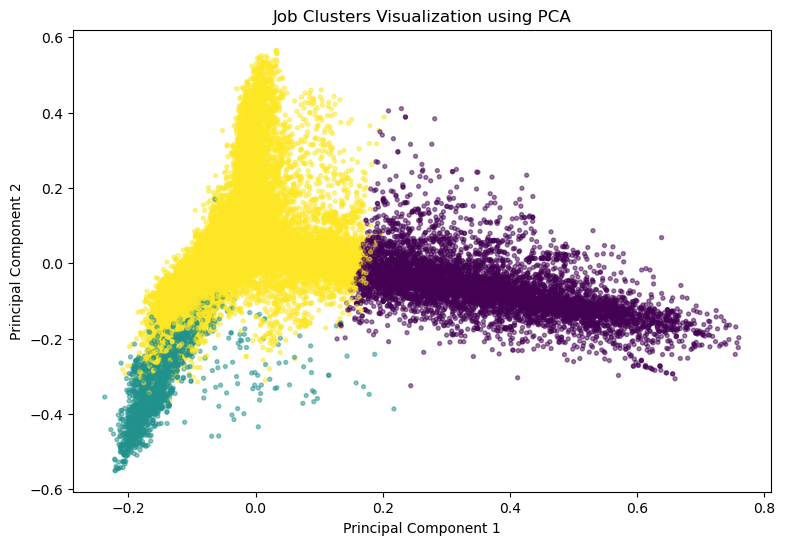

In [14]:
plt.figure(figsize=(9, 6))
plt.scatter(
    job_pca[:, 0],
    job_pca[:, 1],
    c=job_clusters,
    s=8,
    alpha=0.5
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Job Clusters Visualization using PCA")
plt.show()

In [15]:
os.makedirs("../models", exist_ok=True)
joblib.dump(svd, "../models/job_svd.pkl")
joblib.dump(kmeans, "../models/job_kmeans.pkl")
print("SVD model saved successfully!")
print("K-Means model saved successfully!")

SVD model saved successfully!
K-Means model saved successfully!


In [16]:
jobs.to_csv("../data/processed/clustered_jobs.csv", index=False)
print("Clustered job dataset saved successfully!")

Clustered job dataset saved successfully!


In [17]:
print(
    jobs.groupby(
        ["cluster", "cluster_name"]
    ).size()
)

for cluster in sorted(jobs["cluster"].unique()):
    print("\nCluster:", cluster)
    print(
        jobs[
            jobs["cluster"] == cluster
        ][
            ["job_role", "key_skills"]
        ].head(10)
    )

cluster  cluster_name                      
0        Sales & Business Development           6805
1        Technology & IT Consulting             2717
2        General & Other Professional Roles    52251
dtype: int64

Cluster: 0
                                              job_role  \
10                                Sales Ops Specialist   
20   Hospital Business Manager - Govt Institutional...   
35       Talent Acquisition Specialist  - Sales Hiring   
52              Sr Manager - Sales (Building End User)   
57               Admission Officer - Sales & Marketing   
58                          Territory Head - Bangalore   
65            Manager Franchisee Expansion - Bangalore   
75                      Area Sales Manager - Bangalore   
139                     Business Development Associate   
143  General Manager - Corporate Sales - South (Tra...   

                                            key_skills  
10   Computer science,Team management,Analytical,Sa...  
20   Tender Busines